<a href="https://colab.research.google.com/github/cinarergul1/cinarerguldsaprjct/blob/main/EDAA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>



# Creatine Intake and Muscle Growth
## Exploratory Data Analysis (EDA)

In [36]:
# Creatine Intake and Muscle Growth
## Exploratory Data Analysis (EDA)

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

In [38]:
import numpy as np
import pandas as pd

# Orijinal 15 günlük gerçek veri
real_data = {
    'day':      [1,2,3,4,5,6,7,8,9,10,11,12,13,14,15],
    'creatine': [5,5,5,3,5,3,5,3,5,3,5,3,5,3,5],
    'sets':     [12,10,14,0,13,11,15,0,12,10,14,0,13,11,16],
    'sleep':    [7.0,6.5,7.5,8.0,7.0,6.0,8.5,9.0,7.0,6.5,7.5,8.0,7.0,7.5,8.0],
    'protein':  [155,160,170,145,165,155,175,150,168,158,172,148,162,155,180],
    'bench':    [80.0,80.5,81.0,81.0,82.5,82.5,83.0,83.0,84.0,84.0,85.0,85.0,86.0,86.0,87.5],
    'arm':      [33.0,33.1,33.2,33.3,33.4,33.4,33.6,33.7,33.8,33.8,34.0,34.0,34.2,34.2,34.5]
}
real_df = pd.DataFrame(real_data)

# 75 günlük simüle veri
np.random.seed(42)
n = 75
creatine_sim = np.random.choice([3, 5], n)

sim_data = {
    'day':      range(16, 16+n),
    'creatine': creatine_sim,
    'sets':     np.where(creatine_sim == 5,
                    np.random.randint(10, 17, n),
                    np.random.randint(0, 12, n)),
    'sleep':    np.round(np.random.normal(7.2, 0.8, n).clip(5, 10), 1),
    'protein':  np.random.randint(145, 180, n),
    'bench':    np.round(87.5 + np.arange(n)*0.08 + creatine_sim*0.1 + np.random.normal(0, 0.5, n), 1),
    'arm':      np.round(34.5 + np.arange(n)*0.01 + creatine_sim*0.02 + np.random.normal(0, 0.1, n), 2),
}
sim_df = pd.DataFrame(sim_data)

# Birleştir
df = pd.concat([real_df, sim_df], ignore_index=True)
df['creatine_group'] = df['creatine'].apply(lambda x: 'High (5g)' if x == 5 else 'Low (3g)')
print(df.shape)  # (90, 8) olmalı

(90, 8)


In [39]:
print("Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())

Shape: (90, 8)

Data Types:
day                 int64
creatine            int64
sets                int64
sleep             float64
protein             int64
bench             float64
arm               float64
creatine_group     object
dtype: object

Missing Values:
day               0
creatine          0
sets              0
sleep             0
protein           0
bench             0
arm               0
creatine_group    0
dtype: int64


In [40]:
df.describe().round(2)

,day,creatine,sets,sleep,protein,bench,arm
count,90.00,90.00,90.00,90.00,90.00,90.00,90.00
mean,45.50,4.04,9.73,7.27,164.17,89.64,34.74
std,26.12,1.00,4.92,0.77,10.58,3.39,0.55
min,1.00,3.00,0.00,5.70,145.00,80.00,33.00
25%,23.25,3.00,7.00,6.60,155.25,88.40,34.65
50%,45.50,5.00,11.00,7.30,166.00,90.10,34.88
75%,67.75,5.00,13.00,7.78,173.00,92.10,35.11
max,90.00,5.00,16.00,9.20,180.00,94.30,35.48


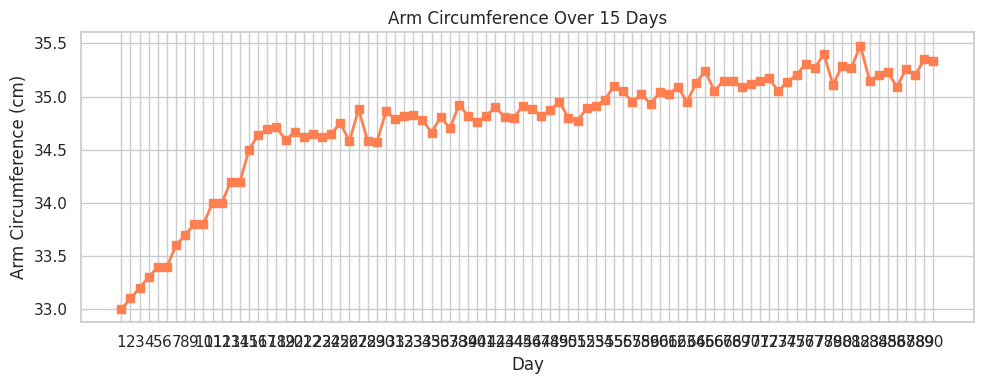

In [41]:
plt.figure(figsize=(10, 4))
plt.plot(df['day'], df['arm'], marker='s', linewidth=2, color='coral')
plt.title('Arm Circumference Over 15 Days')
plt.xlabel('Day')
plt.ylabel('Arm Circumference (cm)')
plt.xticks(df['day'])
plt.tight_layout()
plt.show()

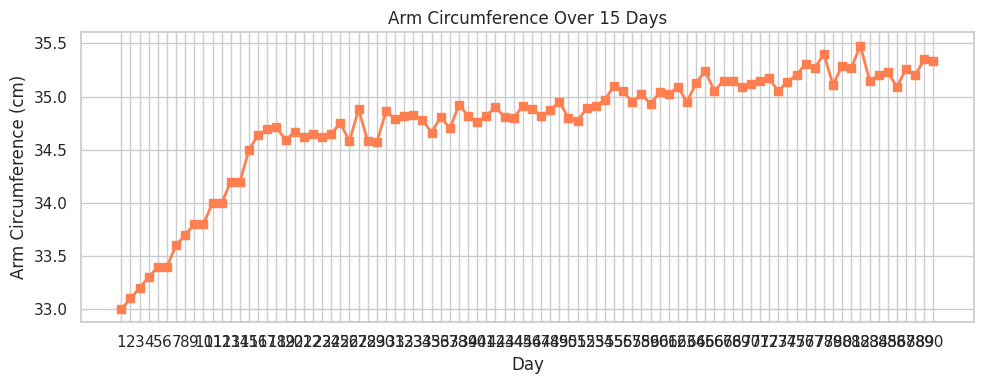

In [42]:
plt.figure(figsize=(10, 4))
plt.plot(df['day'], df['arm'], marker='s', linewidth=2, color='coral')
plt.title('Arm Circumference Over 15 Days')
plt.xlabel('Day')
plt.ylabel('Arm Circumference (cm)')
plt.xticks(df['day'])
plt.tight_layout()
plt.show()

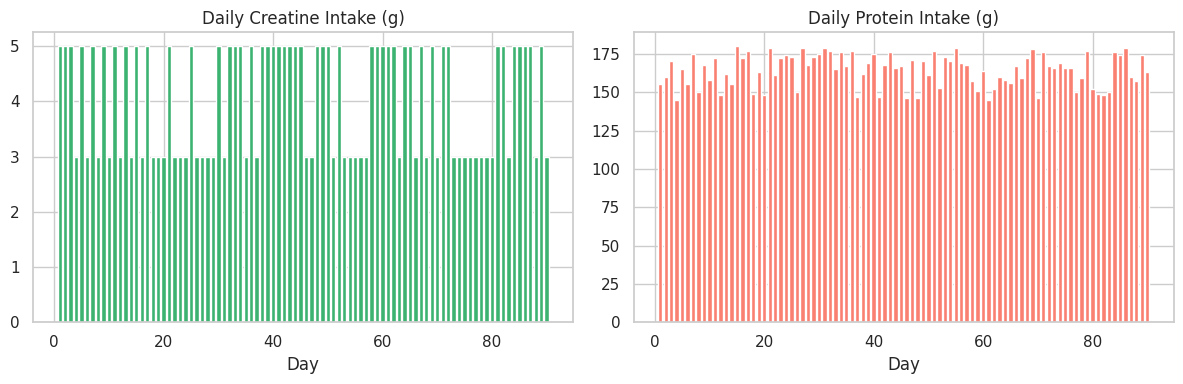

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(df['day'], df['creatine'], color='mediumseagreen')
axes[0].set_title('Daily Creatine Intake (g)')
axes[0].set_xlabel('Day')
axes[1].bar(df['day'], df['protein'], color='salmon')
axes[1].set_title('Daily Protein Intake (g)')
axes[1].set_xlabel('Day')
plt.tight_layout()
plt.show()

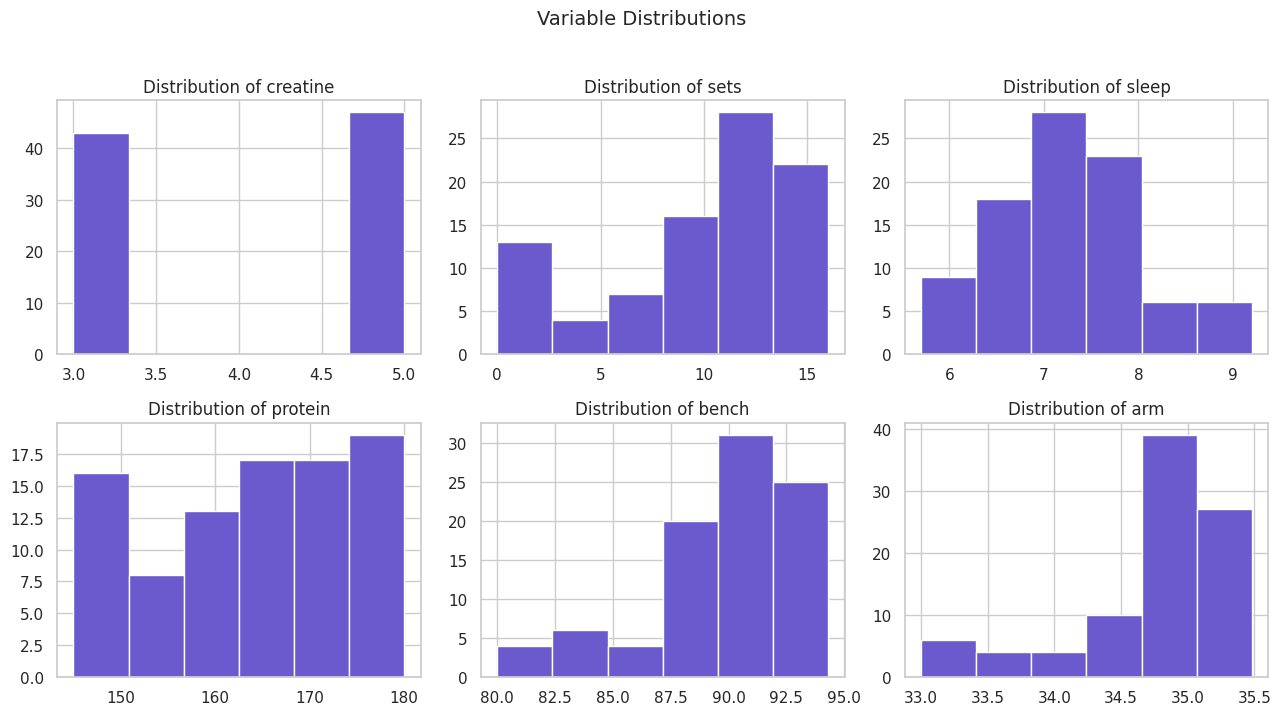

In [44]:
cols = ['creatine', 'sets', 'sleep', 'protein', 'bench', 'arm']
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].hist(df[col], bins=6, color='slateblue', edgecolor='white')
    axes[i].set_title(f'Distribution of {col}')

plt.suptitle('Variable Distributions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

/tmp/ipykernel_9211/4237468054.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='creatine_group', y='bench', ax=axes[0], palette='Set2')
/tmp/ipykernel_9211/4237468054.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='creatine_group', y='arm', ax=axes[1], palette='Set2')


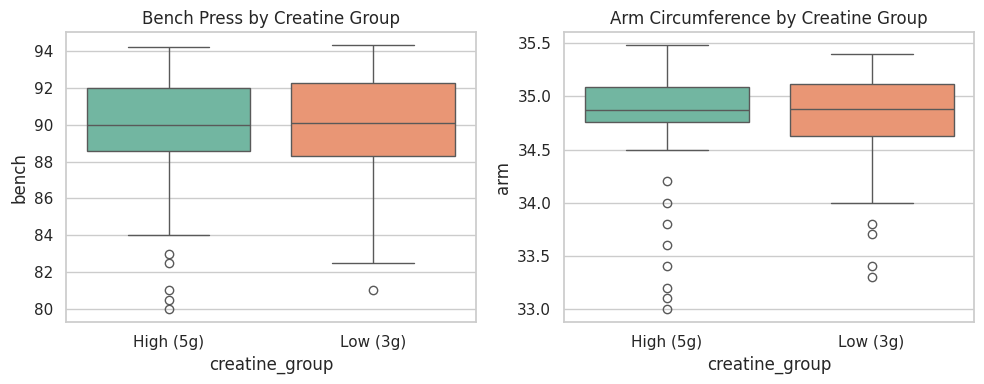

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
sns.boxplot(data=df, x='creatine_group', y='bench', ax=axes[0], palette='Set2')
axes[0].set_title('Bench Press by Creatine Group')
sns.boxplot(data=df, x='creatine_group', y='arm', ax=axes[1], palette='Set2')
axes[1].set_title('Arm Circumference by Creatine Group')
plt.tight_layout()
plt.show()

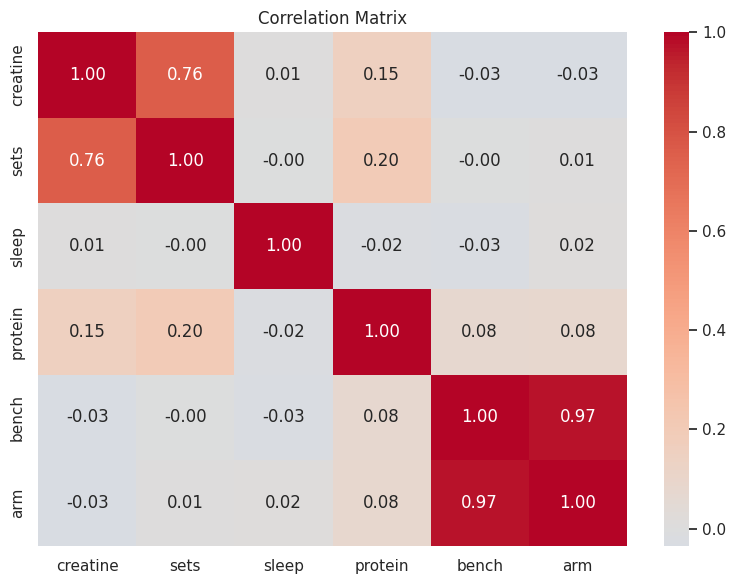

In [46]:
corr_cols = ['creatine', 'sets', 'sleep', 'protein', 'bench', 'arm']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

## Summary of EDA Findings
- Bench press and arm circumference show a steady upward trend over 15 days.
- Creatine was taken at either 3g or 5g doses; rest days (sets=0) coincide with 3g days.
- Sleep averages around 7.4 hours with moderate variation.
- Correlation matrix shows bench and arm are highly correlated with day (time),
  but creatine alone does not show strong linear correlation with performance metrics.